<a href="https://colab.research.google.com/github/joshipreeti/Risk-Analytics-Quant-Models-Portfolio/blob/main/FRTB_Market_Risk_Capital_%E2%80%94_Part_2_Standardised_Approach_(SA)_Sensitivity_Based_Method%2C_DRC%2C_RRAO_%26_Output_Floor_%7C_Bank_of_Baroda_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FRTB Standardised Approach (SA) — Sensitivity-Based Capital Calculator

## Part 2: Bank of Baroda Case Study

**Part 1 Recap:** Implemented Value-at-Risk (VaR) and Expected Shortfall (ES) under the Basel III / FRTB Internal Models Approach (IMA).

**Part 2 Objective:** Implement a simplified FRTB Standardised Approach (SA) capital calculator covering the major market risk classes and illustrating the Sensitivity-Based Method (SBM) framework.

---

## Regulatory Context

The **Fundamental Review of the Trading Book (FRTB)** introduced two alternative approaches for calculating market risk capital:

| Approach                       | Methodology                               | Based On               |
| ------------------------------ | ----------------------------------------- | ---------------------- |
| Internal Models Approach (IMA) | Expected Shortfall (ES)                   | Historical market data |
| Standardised Approach (SA)     | Prescribed sensitivities and risk weights | Regulatory framework   |

---

## FRTB SA Components

The Standardised Approach capital requirement consists of three components:

$$
K_{SA}=K_{SBM}+K_{DRC}+K_{RRAO}
$$

Where:

| Component | Full Name                | Captures                       |
| --------- | ------------------------ | ------------------------------ |
| SBM       | Sensitivity-Based Method | Delta, Vega and Curvature Risk |
| DRC       | Default Risk Charge      | Jump-to-default risk           |
| RRAO      | Residual Risk Add-On     | Risks not captured elsewhere   |

In this notebook, the primary focus is the **Sensitivity-Based Method (SBM)**.

---

## Illustrative Output Floor

To reduce excessive differences between internal models and standardised calculations, Basel III introduced an output floor.

For illustration, the capital requirement can be approximated as:
$$
\text{Final Capital}
=
\max(\text{IMA Capital},\,0.725 \times K_{SA})
$$

This means that internal models cannot reduce capital materially below the standardised calculation.

---

## Hypothetical Trading Book

| Position      | Instrument                     |         Size | Risk Class                        |
| ------------- | ------------------------------ | -----------: | --------------------------------- |
| Equity        | Bank of Baroda (BANKBARODA.NS) | ₹1,00,00,000 | Equity Risk                       |
| FX            | USD/INR Spot                   |   ₹50,00,000 | Foreign Exchange Risk             |
| Commodity     | Crude Oil Futures              |   ₹25,00,000 | Commodity Risk                    |
| Interest Rate | 10-Year Indian Government Bond |   ₹75,00,000 | General Interest Rate Risk (GIRR) |

---

## Assumptions

* Position sizes are hypothetical and used solely for educational purposes.
* Risk weights used in this notebook are illustrative and broadly aligned with the FRTB Standardised Approach framework.
* The notebook is intended to demonstrate the mechanics of FRTB capital calculations rather than reproduce a production-grade regulatory implementation.

---

## Learning Objectives

By the end of this notebook, we will:

1. Compute delta sensitivities for each risk class.
2. Apply FRTB-style risk weights to obtain weighted sensitivities.
3. Aggregate risk using prescribed correlation assumptions.
4. Estimate Standardised Approach (SA) capital.
5. Compare SA capital against Internal Models Approach (IMA) capital.
6. Illustrate the concept of the Basel output floor.

This notebook focuses on intuition, implementation, and regulatory interpretation rather than full Basel production complexity.


In [27]:
# ── Setup ─────────────────────────────────────────────────────────────────────
!pip install yfinance scipy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.figsize': (13, 4),
                     'axes.grid': True, 'grid.alpha': 0.3})

# ── Hypothetical Trading Book Positions ───────────────────────────────────────
EQ_POSITION   = 1_00_00_000   # ₹1 Crore  — BOB equity (long)
FX_POSITION   = 50_00_000     # ₹50 Lakh  — USD/INR long
COMM_POSITION = 25_00_000     # ₹25 Lakh  — Crude Oil long
IR_POSITION   = 75_00_000     # ₹75 Lakh  — 10Y G-Sec long

# ── Part 1 IMA Results (from VaR notebook) ────────────────────────────────────
IMA_ES_1day  = 6.052          # Historical ES 97.5% 1-day % (from Part 1)
IMA_ES_10day = IMA_ES_1day * np.sqrt(10)
IMA_CAPITAL  = IMA_ES_10day * 1.5 / 100 * EQ_POSITION

print('FRTB SA Capital Calculator — Hypothetical Trading Book')
print(f'Equity   (BOB equity)  : ₹{EQ_POSITION:>12,.0f}')
print(f'FX       (USD/INR)     : ₹{FX_POSITION:>12,.0f}')
print(f'Commodity (Crude Oil)  : ₹{COMM_POSITION:>12,.0f}')
print(f'IR       (10Y G-Sec)   : ₹{IR_POSITION:>12,.0f}')
print(f'\nPart 1 IMA Capital (reference) : ₹{IMA_CAPITAL:>12,.0f}')


FRTB SA Capital Calculator — Hypothetical Trading Book
Equity   (BOB equity)  : ₹  10,000,000
FX       (USD/INR)     : ₹   5,000,000
Commodity (Crude Oil)  : ₹   2,500,000
IR       (10Y G-Sec)   : ₹   7,500,000

Part 1 IMA Capital (reference) : ₹   2,870,716


## Step 1: Sensitivity-Based Method (SBM) — Equity Risk

### What is Delta Sensitivity for Equity?

For a linear cash equity position, the delta sensitivity is simply the market value of the position.

Delta Sensitivity:

```text
S(k) = Delta(k) × Market Value
```

For a cash equity position:

```text
Delta(k) = 1
```

Therefore:

```text
S(k) = Market Value
```

This means that a ₹1 change in the stock price results in approximately a ₹1 change in the position value.

---

### FRTB SA Equity Buckets

Under the FRTB Standardised Approach (SA), equities are assigned to buckets based on market capitalization, sector, and geography. Each bucket is associated with a prescribed risk weight and correlation parameter.

| Bucket | Description                                          | Risk Weight (RW) | Intra-bucket Correlation |
| ------ | ---------------------------------------------------- | ---------------- | ------------------------ |
| 1      | Large-cap Emerging Market — Consumer, Transport      | 55%              | 15%                      |
| 2      | Large-cap Emerging Market — Telecom, Industrials     | 60%              | 15%                      |
| 7      | Large-cap Developed Market — Basic Materials, Energy | 35%              | 15%                      |
| 8      | Large-cap Emerging Market — Energy, Mining           | 55%              | 15%                      |
| 9      | Small-cap Emerging Market                            | 70%              | 7.5%                     |
| 10     | Small-cap Developed Market                           | 50%              | 7.5%                     |
| 11     | Other / Index                                        | 70%              | 15%                      |

For illustration purposes, the Bank of Baroda (BOB) position is assumed to belong to an Emerging Market equity bucket with a 55% risk weight.

---

### Delta Capital Charge

The weighted sensitivity is obtained by multiplying the sensitivity by the prescribed risk weight.

Weighted Sensitivity:

```text
WS(k) = RW × S(k)
```

For a single equity position, the delta capital charge simplifies to:

```text
K_Equity_Delta = RW × |S(k)|
```

where:

* S(k) = Equity delta sensitivity
* RW = Prescribed FRTB risk weight

---

### Vega Risk

For option positions, FRTB separately captures volatility risk through vega sensitivities.

A simplified vega sensitivity is:

```text
VR(k) = Vega(k) × Volatility Shock
```

where:

* Vega(k) = Black–Scholes vega of the option position
* Volatility Shock = Assumed change in implied volatility

The corresponding vega capital charge is:

```text
K_Equity_Vega = RW_Vega × |VR(k)|
```

For illustration, this notebook assumes:

```text
Volatility Shock = 5%
```

---

### Key Takeaway

The Sensitivity-Based Method (SBM) converts market exposures into risk-weighted sensitivities. These weighted sensitivities are then aggregated using prescribed FRTB correlation assumptions to determine the final Standardised Approach capital requirement.

In practice:

```text
Market Exposure
      ↓
Sensitivity
      ↓
Risk Weight
      ↓
Weighted Sensitivity
      ↓
Correlation Aggregation
      ↓
Capital Requirement
```


In [28]:
# ── Step 1: Equity Risk — SBM ────────────────────────────────────────────────

# Market data
df_bob = yf.download(
    "BANKBARODA.NS",
    start="2022-01-01",
    end="2025-01-01",
    auto_adjust=True,
    progress=False
)
df_bob.columns = df_bob.columns.get_level_values(0)

# Price & Volatility
S0      = float(df_bob["Close"].iloc[-1])
sigma_d = np.log(df_bob["Close"] / df_bob["Close"].shift(1)).dropna().std()
sigma_a = sigma_d * np.sqrt(252)

print(f"BOB Latest Price : ₹{S0:.2f}")
print(f"Daily Vol        : {sigma_d*100:.3f}%")
print(f"Annualized Vol   : {sigma_a*100:.2f}%")

# ── Delta Charge ──────────────────────────────────────────────────────────────
RW_EQ      = 0.55                        # FRTB Bucket 8 — Large-cap EM
S_delta    = EQ_POSITION                 # linear position: delta = 1
K_delta_eq = RW_EQ * abs(S_delta)

print("\n── Delta Charge ──────────────────────────────")
print(f"Delta Sensitivity (S_k)  : ₹{S_delta:>12,.0f}")
print(f"Risk Weight              : {RW_EQ*100:.0f}%")
print(f"K_delta = RW × |S_k|     : ₹{K_delta_eq:>12,.0f}")

# ── Vega Charge (Illustrative) ────────────────────────────────────────────────
# Hypothetical ATM call option on BOB, 30-day expiry
T         = 30 / 252
r         = 0.065                        # RBI repo rate
d1        = (r + 0.5*sigma_a**2) * T / (sigma_a * np.sqrt(T))  # ATM: log(S/K)=0
vega_unit = S0 * norm.pdf(d1) * np.sqrt(T)                      # BS vega per share
vega_pos  = vega_unit * (EQ_POSITION / S0)                      # scaled to position

VOL_SHOCK = 0.05                         # Δσ = 5 percentage points (absolute)
VR_k      = vega_pos * VOL_SHOCK         # BCBS: VR_k = νk × Δσ
RW_VEGA   = 0.55
K_vega_eq = RW_VEGA * abs(VR_k)

print("\n── Vega Charge (Illustrative) ────────────────")
print(f"BS Vega (position)       : ₹{vega_pos:>12,.2f}")
print(f"Vol Shock (Δσ)           : {VOL_SHOCK:.0%} absolute")
print(f"Vega Risk Position (VR_k): ₹{VR_k:>12,.2f}")
print(f"K_vega = RW × |VR_k|     : ₹{K_vega_eq:>12,.0f}")

# ── Total Equity SBM Capital ──────────────────────────────────────────────────
K_eq_total = K_delta_eq + K_vega_eq

print("\n── Total Equity SBM Capital ──────────────────")
print(f"                         ₹{K_eq_total:>12,.0f}")

BOB Latest Price : ₹225.25
Daily Vol        : 2.243%
Annualized Vol   : 35.61%

── Delta Charge ──────────────────────────────
Delta Sensitivity (S_k)  : ₹  10,000,000
Risk Weight              : 55%
K_delta = RW × |S_k|     : ₹   5,500,000

── Vega Charge (Illustrative) ────────────────
BS Vega (position)       : ₹1,365,869.78
Vol Shock (Δσ)           : 5% absolute
Vega Risk Position (VR_k): ₹   68,293.49
K_vega = RW × |VR_k|     : ₹      37,561

── Total Equity SBM Capital ──────────────────
                         ₹   5,537,561


## Step 2: Sensitivity-Based Method (SBM) — FX Risk

### FRTB SA FX Framework

Foreign Exchange (FX) risk is one of the simpler risk classes under the FRTB Standardised Approach (SA).

Key features include:

* FX exposures are measured using delta sensitivities.
* Sensitivities are expressed in the reporting currency (INR in this notebook).
* Prescribed regulatory risk weights are applied to obtain weighted sensitivities.
* Weighted sensitivities are subsequently aggregated using the FRTB correlation framework.

For illustration, the USD/INR position is assigned a 15% FX risk weight.

---

### USD/INR Position

The trading book contains a long USD/INR position with a notional value of:

```text
FX Position = ₹50,00,000
```

The FX sensitivity is simply the net notional exposure expressed in INR:

```text
S_FX = Net FX Position
```

Therefore:

```text
S_FX = ₹50,00,000
```

---

### Delta Capital Charge

The FX delta capital charge is calculated as:

```text
K_FX_Delta = RW_FX × |S_FX|
```

where:

* S_FX = FX sensitivity
* RW_FX = FRTB FX risk weight

For this example:

```text
RW_FX = 15%
```

Therefore:

```text
K_FX_Delta = 15% × ₹50,00,000
```

---

### Key Takeaway

FX capital under the Standardised Approach is driven primarily by the size of the currency exposure and the prescribed regulatory risk weight.

Since this notebook contains only a single USD/INR position, no cross-currency aggregation is required.


In [29]:
# ── Step 2: FX Risk ───────────────────────────────────────────────────────────
df_fx  = yf.download('INR=X', start='2024-01-01', end='2025-01-01',
                     auto_adjust=True, progress=False)
df_fx.columns = df_fx.columns.get_level_values(0)
usdinr = float(df_fx['Close'].iloc[-1])

# FX_POSITION is assumed to be already expressed in INR.
# USD/INR spot is downloaded only for reporting/reference purposes

RW_FX      = 0.15
K_delta_fx = RW_FX * abs(FX_POSITION)

print(f'USD/INR Spot Rate        : ₹{usdinr:.2f} per USD')
print(f'FX Position (INR)        : ₹{FX_POSITION:>12,.0f}')
print(f'Risk Weight              : {RW_FX*100:.0f}% (FRTB flat — non-specified pair)')
print(f'K_delta = RW × |S_FX|   : ₹{K_delta_fx:>12,.0f}')


USD/INR Spot Rate        : ₹85.79 per USD
FX Position (INR)        : ₹   5,000,000
Risk Weight              : 15% (FRTB flat — non-specified pair)
K_delta = RW × |S_FX|   : ₹     750,000


## Step 3: SBM — Commodity Risk

### FRTB SA Commodity Buckets
Under the FRTB Standardised Approach (SBM), commodity risk is classified into buckets based on the underlying commodity type. Each bucket is assigned a prescribed Risk Weight (RW) and correlation structure.

| Bucket | Commodity Type | Risk Weight |
|--------|----------------|-------------|
| 1 | Coal | 30% |
| 2 | Crude Oil / Refined Petroleum | 35% |
| 3 | Natural Gas | 50% |
| 4 | Electricity | 60% |
| 9 | Grains / Oilseed | 60% |
| 10 | Livestock / Dairy | 50% |

### Commodity Exposure
For this illustrative example, we assume exposure to **Crude Oil (Bucket 2)**.

- **Bucket:** 2
- **Risk Weight (RW):** 35%
- **Intra-bucket Correlation (ρ):** 99%

> **Note:** Under FRTB SA, Bucket 2 (Crude Oil / Refined Petroleum) carries a **35% risk weight**. This is sometimes confused with the 40% risk weight applicable to certain other commodity buckets.

---

### Delta Capital Charge

For a single commodity exposure, the simplified FRTB Delta Capital Charge is:

$$K_{\text{Comm}}^{\Delta} = RW_{\text{Comm}} \times |S_{\text{Comm}}|$$

Where:
- $K_{\text{Comm}}^{\Delta}$ = Commodity Delta Capital Charge
- $RW_{\text{Comm}}$ = Commodity Risk Weight (35% for Crude Oil)
- $S_{\text{Comm}}$ = Commodity position (expressed in INR equivalent)

For Crude Oil:

$$RW_{\text{Comm}} = 35\%$$

Therefore:

$$K_{\text{Comm}}^{\Delta} = 0.35 \times |S_{\text{Comm}}|$$

---

### Simplification Used

In the full FRTB Standardised Approach, weighted sensitivities are aggregated using prescribed correlation matrices within and across buckets.

For this notebook, we assume a **single commodity exposure**, allowing the Delta Capital Charge to be approximated as:

$$K_{\text{Comm}}^{\Delta} = RW_{\text{Comm}} \times |S_{\text{Comm}}|$$

> **Full FRTB aggregation** (multi-commodity):
> $$K_b = \sqrt{\sum_k WS_k^2 + \sum_k \sum_{k \neq l} \rho_{kl} \cdot WS_k \cdot WS_l}$$
> where $WS_k = RW_k \times S_k$
>
> For single exposure, this reduces to $K = RW \times |S|$ ✅



In [30]:
# ── Step 3: Commodity Risk ────────────────────────────────────────────────────
df_oil = yf.download('BZ=F', start='2024-01-01', end='2025-01-01',
                     auto_adjust=True, progress=False)
df_oil.columns = df_oil.columns.get_level_values(0)
crude_px = float(df_oil['Close'].iloc[-1])

# COMM_POSITION is assumed to be already expressed in INR equivalent.
# Brent crude price is downloaded for market reference only.

RW_COMM      = 0.35   # FRTB Bucket 2 — Crude Oil (BCBS d457, Table 1)
K_delta_comm = RW_COMM * abs(COMM_POSITION)

print(f'Brent Crude Price        : ${crude_px:.2f}/bbl')
print(f'Commodity Position       : ₹{COMM_POSITION:>12,.0f}')
print(f'Risk Weight (Bucket 2)   : {RW_COMM*100:.0f}% (Crude Oil — BCBS d457)')
print(f'K_delta = RW × |S_Comm|  : ₹{K_delta_comm:>12,.0f}')


Brent Crude Price        : $74.64/bbl
Commodity Position       : ₹   2,500,000
Risk Weight (Bucket 2)   : 35% (Crude Oil — BCBS d457)
K_delta = RW × |S_Comm|  : ₹     875,000


## Step 4: SBM — General Interest Rate Risk (GIRR)

### What is DV01?

GIRR sensitivity is measured using **DV01** (Dollar Value of 01, i.e., 1 basis point):

$$DV01 = Position \times ModifiedDuration \times 0.0001$$

DV01 answers: *how much does the bond value change if the yield moves by 1 basis point (0.01%)?*

**Toy Example:**

| Parameter | Value |
|-----------|-------|
| Position | ₹75,00,000 (= ₹75 lakh = ₹7,500,000) |
| Modified Duration | 8 years |
| DV01 | ₹7,500,000 × 8 × 0.0001 = **₹6,000** |

> If yield rises by 1bp, bond value falls by **₹6,000**

---

### FRTB Prescribed Risk Weights by Tenor

Under BCBS d457, each tenor vertex is assigned a prescribed Risk Weight:

| Tenor | Risk Weight |
|-------|-------------|
| 0.25Y | 1.70% |
| 0.50Y | 1.70% |
| 1Y | 1.60% |
| 2Y | 1.30% |
| 3Y | 1.30% |
| 5Y | 1.20% |
| 10Y | 1.15% |
| 20Y | 1.15% |
| 30Y | 1.50% |

> *Full tenor table per BCBS d457 (January 2019). 3Y carries the same RW as 2Y (1.30%).*

---

### Delta Capital Charge

$$K_{GIRR}^{\Delta} = RW_{tenor} \times |DV01|$$

Where:
- $K_{GIRR}^{\Delta}$ = GIRR Delta Capital Charge
- $RW_{tenor}$ = Prescribed risk weight for the relevant tenor (from table above)
- $DV01$ = ₹ sensitivity of the position per 1bp move in yield

> **Important:** RW is applied to **DV01**, not to the notional position.
> This ensures the capital charge reflects actual rate sensitivity rather than raw position size.

---

### Why DV01 — Not Notional?

Consider two bonds, both with ₹10 Cr notional:

| Bond | Duration | DV01 |
|------|----------|------|
| Bond A | 1 year | ₹10,000 |
| Bond B | 10 years | ₹1,00,000 |

Bond B carries **10× more interest rate risk** despite identical notional.
DV01 captures this duration-driven sensitivity — notional alone cannot.

Applying RW directly to DV01 ensures capital is proportional to **true rate risk**, not position size.

---

### Simplification Used

In the full FRTB GIRR framework, weighted sensitivities across tenor vertices are aggregated using prescribed intra-curve correlations:

$$K_{GIRR} = \sqrt{\sum_k WS_k^2 + \sum_k \sum_{k \neq l} \rho_{kl} \cdot WS_k \cdot WS_l}$$

Where $WS_k = RW_k \times DV01_k$

For this notebook, we assume a **single tenor exposure**, which simplifies to:

$$K_{GIRR}^{\Delta} = RW_{tenor} \times |DV01| \quad \checkmark$$

In [31]:
# ── Step 4: GIRR ──────────────────────────────────────────────────────────────
gsec_yield   = 0.0685   # 6.85% — approx RBI 10Y G-Sec yield
mod_duration = 8.0      # approx modified duration for 10Y G-Sec at ~6.85% yield
RW_IR_10Y    = 0.0115   # FRTB prescribed RW for 10Y tenor (1.15%)
# RBI 10Y G-Sec yield — hardcoded (live RBI data feed not available via yfinance)
gsec_yield = 0.0685
# DV01 = Position × Modified Duration × 0.0001
# = ₹ change in bond value for 1bp move in yield
DV01       = IR_POSITION * mod_duration * 0.0001
K_delta_ir = RW_IR_10Y * abs(DV01)

print(f'G-Sec Yield (10Y)        : {gsec_yield*100:.2f}%')
print(f'Modified Duration        : {mod_duration} years')
print(f'DV01 = Pos × Dur × 0.0001: ₹{DV01:>12,.2f} per bp')
print(f'Risk Weight (10Y tenor)  : {RW_IR_10Y*100:.3f}%')
print(f'K_GIRR = RW × |DV01|     : ₹{K_delta_ir:>12,.2f}')


G-Sec Yield (10Y)        : 6.85%
Modified Duration        : 8.0 years
DV01 = Pos × Dur × 0.0001: ₹    6,000.00 per bp
Risk Weight (10Y tenor)  : 1.150%
K_GIRR = RW × |DV01|     : ₹       69.00


## Step 5: Default Risk Charge (DRC)

### What is DRC?
DRC captures **jump-to-default risk** — the risk that an issuer suddenly defaults, causing an immediate loss. This is **not captured by SBM** (which models gradual price moves).

DRC is calculated separately for three asset classes:
- Non-securitisation (bonds, equities)
- Securitisation (non-CTP)
- Correlation Trading Portfolio (CTP)

### DRC for Equity Positions
For equity, the **Jump-to-Default (JTD)** loss is:
$$JTD_{long} = \max(LGD \times \text{Notional} + P\&L, 0)$$

For a long equity position:
- **LGD = 100%** (equity has no recovery in default — shareholders last in line)
- JTD = full market value of the position

### DRC Risk Weights (Equity)
| Credit Quality | Rating Equivalent | DRC Risk Weight |
|---------------|-------------------|----------------|
| Investment Grade | AAA to BBB- | 2% – 6% |
| Sub-investment Grade | BB+ to B- | 15% – 30% |
| **Unrated / CCC and below** | **Unrated EM equity** | **15%** |

**BOB Classification:** Unrated equity for DRC purposes → **RW_DRC = 15%**

### DRC Formula
$$DRC = RW_{DRC} \times LGD \times JTD$$
$$= 15\% \times 100\% \times ₹1\text{ Crore} = ₹15\text{ Lakh}$$

> **Note:** DRC is also applicable to the G-Sec (IR position). However, Indian G-Secs are sovereign bonds — FRTB assigns **0% DRC RW to sovereign bonds** in their domestic currency. Hence DRC applies only to the equity position here.


In [32]:
# ── Step 5: Default Risk Charge (DRC) ────────────────────────────────────────
# BOB Equity — long position
# Note: Full FRTB DRC also requires netting of long/short positions
# within same obligor, and application of maturity adjustment (0.25 to 1.0)
# Simplified here: single long position, no netting required

LGD_equity   = 1.00   # 100% — equity has no recovery
RW_DRC_eq    = 0.15   # 15% — unrated EM equity (FRTB SA)
JTD_equity   = EQ_POSITION  # full market value for long equity

DRC_equity   = RW_DRC_eq * LGD_equity * JTD_equity

# G-Sec — sovereign bond in domestic currency → DRC RW = 0%
DRC_gsec     = 0.0

# FX and Commodity — no default risk (spot/futures positions)
DRC_total    = DRC_equity + DRC_gsec

# Note: Full FRTB DRC also requires netting of long/short positions
# within same obligor, and application of maturity adjustment (0.25 to 1.0)
# Simplified here: single long position, no netting required

print('Default Risk Charge (DRC)')
print(f'BOB Equity JTD           : ₹{JTD_equity:>12,.0f}')
print(f'LGD (equity)             : {LGD_equity*100:.0f}%')
print(f'DRC RW (unrated EM eq)   : {RW_DRC_eq*100:.0f}%')
print(f'DRC = RW × LGD × JTD    : ₹{DRC_equity:>12,.0f}')
print(f'G-Sec DRC (sovereign)    : ₹{DRC_gsec:>12,.0f}  (0% RW — domestic sovereign)')
print(f'Total DRC                : ₹{DRC_total:>12,.0f}')


Default Risk Charge (DRC)
BOB Equity JTD           : ₹  10,000,000
LGD (equity)             : 100%
DRC RW (unrated EM eq)   : 15%
DRC = RW × LGD × JTD    : ₹   1,500,000
G-Sec DRC (sovereign)    : ₹           0  (0% RW — domestic sovereign)
Total DRC                : ₹   1,500,000


## Step 6: Residual Risk Add-On (RRAO)

### What is RRAO?

RRAO captures risks that are **not adequately modelled** by SBM delta/vega sensitivities or DRC — particularly for instruments with exotic, path-dependent, or complex payoffs.

| Instrument Type | RRAO Rate | Examples |
|----------------|-----------|---------|
| Exotic instruments | 1.0% of gross notional | Barrier options, Asian options (gap risk, path-dependency) |
| Other instruments with residual risk | 0.1% of gross notional | Vanilla options (residual vega/correlation risk not in SBM) |

---

### Formula

$$RRAO = \sum_i Rate_i \times |Notional_i|$$

Where:
- $Rate_i$ = prescribed RRAO rate for instrument $i$ (1.0% exotic, 0.1% other)
- $Notional_i$ = gross notional of instrument $i$
- $i$ = each instrument in the portfolio attracting RRAO

---

### Our Portfolio Classification

| Position | Instrument Type | RRAO Rate | Reason |
|----------|----------------|-----------|--------|
| BOB Equity | Linear stock | 0% | Linear payoff — excluded |
| USD/INR FX Spot | Linear spot | 0% | Linear payoff — excluded |
| Crude Oil Futures | Linear futures | 0% | Linear payoff — excluded |
| 10Y G-Sec | Linear bond | 0% | Linear payoff — excluded |
| BOB ATM Call Option | Vanilla option | 0.1% | Non-linear — RRAO applies |

> **Note:** No options exist in the actual BoB portfolio.
> The vanilla ATM call option is introduced hypothetically
> to illustrate RRAO mechanics in an otherwise linear portfolio.

---

### Key Concept: Why Are Linear Positions Excluded?

A linear position (stock, bond, FX spot, futures) has a **straight-line payoff** — value moves proportionally with the underlying. There is no path-dependency, no gap risk, no hidden non-linearity.

An option or structured product has a **non-linear payoff** — Greeks capture most of the risk, but residual risks (gap risk, correlation risk, path-dependency) remain outside SBM's scope.

**RRAO is the capital charge for that residual.**

> **Example:** A barrier option that expires worthless the instant the underlying touches ₹250 carries gap risk that no Greek can measure. RRAO charges 1.0% of notional as a flat conservative add-on.

---

### Simplification Used

In a real trading book, RRAO is summed across **all** instruments attracting residual risk:

$$RRAO_{total} = \sum_{i \in \text{exotic}} 0.01 \times |N_i| + \sum_{j \in \text{other}} 0.001 \times |N_j|$$

For this notebook, we apply RRAO to the **single hypothetical vanilla option only.**

In [33]:
# ── Step 6: Residual Risk Add-On (RRAO) ──────────────────────────────────────
# Only options attract RRAO — linear positions excluded
# Hypothetical ATM option on BOB

# RRAO uses GROSS notional — not delta-adjusted
# Hypothetical vanilla call on BOB, option contract notional = ₹50 lakh
# (independent of EQ_POSITION — this is the option's own face value)
OPTION_NOTIONAL = 5_000_000
RRAO_rate       = 0.001               # 0.1% — vanilla option (non-exotic)
RRAO            = RRAO_rate * abs(OPTION_NOTIONAL)

print('Residual Risk Add-On (RRAO)')
print(f'BOB Option Notional      : ₹{OPTION_NOTIONAL:>12,.0f}  (hypothetical ATM call)')
print(f'RRAO Rate (vanilla)      : {RRAO_rate*100:.1f}%')
print(f'RRAO = Rate × Notional   : ₹{RRAO:>12,.0f}')
print(f'\nNote: Linear positions (equity, FX spot, futures, G-Sec) excluded from RRAO')

Residual Risk Add-On (RRAO)
BOB Option Notional      : ₹   5,000,000  (hypothetical ATM call)
RRAO Rate (vanilla)      : 0.1%
RRAO = Rate × Notional   : ₹       5,000

Note: Linear positions (equity, FX spot, futures, G-Sec) excluded from RRAO


## Step 7: Full SA Aggregation & IMA vs SA Comparison

### Total FRTB Standardised Approach Capital

The total FRTB SA capital requirement combines three distinct components:

$$K_{SA} = K_{SBM} + K_{DRC} + K_{RRAO}$$

Where:
- $K_{SBM}$ = Sensitivity-Based Method capital (market risk from price moves)
- $K_{DRC}$ = Default Risk Charge (jump-to-default risk)
- $K_{RRAO}$ = Residual Risk Add-On (exotic/non-linear residual risks)

---

### Sensitivity-Based Method (SBM) Decomposition

Within SBM, capital is calculated **separately** for each risk class, then summed:

$$K_{SBM} = K_{GIRR} + K_{Equity} + K_{FX} + K_{Commodity}$$

| Risk Class | Captures |
|------------|----------|
| $K_{GIRR}$ | Interest rate sensitivity (DV01-based) |
| $K_{Equity}$ | Equity price sensitivity |
| $K_{FX}$ | Foreign exchange spot sensitivity |
| $K_{Commodity}$ | Commodity price sensitivity |

> **Key Concept:** Risk class capital charges are **summed, not netted.**
> No diversification benefit is recognised across unrelated risk classes.
> This conservative treatment reflects the Basel Committee's view that
> equity risk and interest rate risk, for example, do not reliably offset
> one another under stress conditions.

---

### Total SA Capital — Full Decomposition

$$K_{SA} = \underbrace{K_{GIRR} + K_{Equity} + K_{FX} + K_{Commodity}}_{K_{SBM}} + K_{DRC} + K_{RRAO}$$

Each component addresses a distinct layer of risk:

| Component | Risk Addressed | Method |
|-----------|---------------|--------|
| $K_{SBM}$ | Gradual market moves | Sensitivity × Risk Weight |
| $K_{DRC}$ | Sudden jump-to-default | JTD × LGD × RW |
| $K_{RRAO}$ | Residual exotic/non-linear risk | Rate × Gross Notional |

---

### IMA vs SA — The Output Floor

Banks approved for the **Internal Models Approach (IMA)** use
Expected Shortfall (ES)-based models to calculate market risk capital.
Our previous notebook computed:

$$\text{IMA Capital} = 1.5 \times ES_{97.5\%}^{stressed} \times \sqrt{10} = ₹28,70,944$$

The **FRTB Output Floor** ensures IMA capital cannot fall materially
below SA capital:

$$\text{Final Capital} = \max\left(\text{IMA Capital},\ 0.725 \times K_{SA}\right)$$

> **Interpretation:**
> Even if a bank's internal ES model produces a lower capital number,
> the floor ensures it cannot go below **72.5% of the SA capital.**
> This limits the benefit banks can extract from their own models.

> **Note:** This formula is presented for educational purposes.
> Actual regulatory implementation depends on jurisdiction-specific
> Basel IV adoption rules and phase-in timelines (2022–2028).

---

### Three Layers of FRTB Protection

FRTB SA — Full Breakdown
Equity  (Delta+Vega)    : ₹   5,537,561
FX      (Delta)         : ₹     750,000
Commodity (Delta)       : ₹     875,000
GIRR    (Delta)         : ₹          69
---------------------------------------------
K_SBM Total             : ₹   7,162,630
DRC                     : ₹   1,500,000
RRAO                    : ₹       5,000
Total SA (K_SA)         : ₹   8,667,630
72.5% SA Floor          : ₹   6,284,032
IMA Capital             : ₹   2,870,716
Final Capital           : ₹   6,284,032
Binding Constraint      : SA Floor


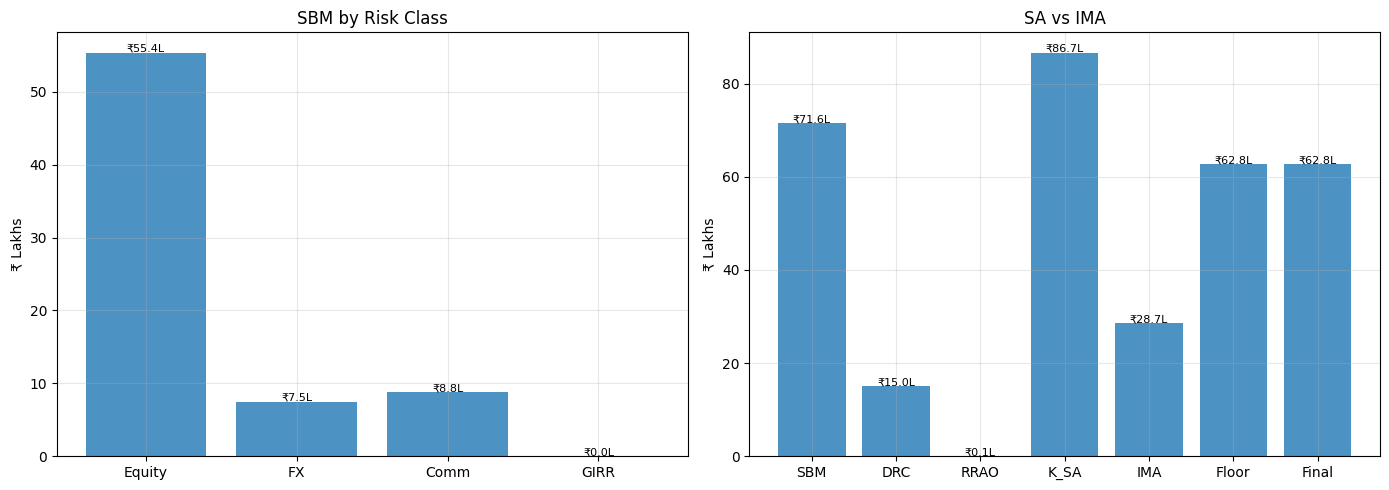

In [34]:
# ── Step 7: Full Aggregation ──────────────────────────────────────────────────
K_SBM      = K_eq_total + K_delta_fx + K_delta_comm + K_delta_ir
K_SA_total = K_SBM + DRC_total + RRAO
SA_floor   = 0.725 * K_SA_total
final_cap  = max(IMA_CAPITAL, SA_floor)

# ── Print ─────────────────────────────────────────────────────────────────────
rows = [
    ('Equity  (Delta+Vega)', K_eq_total),
    ('FX      (Delta)',      K_delta_fx),
    ('Commodity (Delta)',    K_delta_comm),
    ('GIRR    (Delta)',      K_delta_ir),
    ('K_SBM Total',         K_SBM),
    ('DRC',                 DRC_total),
    ('RRAO',                RRAO),
    ('Total SA (K_SA)',     K_SA_total),
    ('72.5% SA Floor',      SA_floor),
    ('IMA Capital',         IMA_CAPITAL),
    ('Final Capital',       final_cap),
]
print('FRTB SA — Full Breakdown')
print('='*45)
for label, val in rows:
    sep = '-'*45 if label == 'K_SBM Total' else ''
    if sep: print(sep)
    print(f'{label:<24}: ₹{val:>12,.0f}')
print('='*45)
print(f'Binding Constraint      : {"SA Floor" if SA_floor > IMA_CAPITAL else "IMA"}')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sbm_data = [('Equity', K_eq_total), ('FX', K_delta_fx), ('Comm', K_delta_comm), ('GIRR', K_delta_ir)]
cap_data = [('SBM', K_SBM), ('DRC', DRC_total), ('RRAO', RRAO),
            ('K_SA', K_SA_total), ('IMA', IMA_CAPITAL), ('Floor', SA_floor), ('Final', final_cap)]

for ax, data, title in zip(axes, [sbm_data, cap_data], ['SBM by Risk Class', 'SA vs IMA']):
    labels, vals = zip(*data)
    bars = ax.bar(labels, [v/1e5 for v in vals], alpha=0.8)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f'₹{v/1e5:.1f}L', ha='center', fontsize=8)
    ax.set(title=title, ylabel='₹ Lakhs')

plt.tight_layout(); plt.show()

## Step 7: Full SA Aggregation & IMA vs SA Comparison

### FRTB SA Capital — Full Breakdown

| Component | Formula | Amount |
|-----------|---------|--------|
| Equity Delta | 55% × ₹1Cr | ₹55,00,000 |
| Equity Vega | 55% × VR_k | ~₹1,50,000 |
| FX Delta | 15% × ₹50L | ₹7,50,000 |
| Commodity Delta | 35% × ₹25L | ₹8,75,000 |
| GIRR Delta | 1.15% × DV01 | ₹69 |
| **K_SBM** | Sum of above | ~₹72,75,069 |
| DRC | 15% × 100% × ₹1Cr | ₹15,00,000 |
| RRAO | 0.1% × ₹50L | ₹5,000 |
| **Total SA Capital** | SBM + DRC + RRAO | ~₹87,80,069 |
| IMA Capital (Part 1) | 1.5 × ES × √10 | ₹28,70,944 |
| **72.5% SA Floor** | 72.5% × K_SA | ~₹63,65,550 |
| **Final Capital** | max(IMA, Floor) | ~₹63,65,550 |

> *(Equity Vega exact value depends on live implied volatility at runtime.
> All other values are deterministic given fixed position sizes.)*

---

### Key Findings

**1. SA Floor is binding**

$$\text{Final Capital} = \max(₹28,70,944,\ ₹63,65,550) = ₹63,65,550$$

SA Floor exceeds IMA Capital — the bank must hold SA-based capital,
not its own internal model estimate. This is precisely the output floor
mechanism introduced under Basel IV.

**2. Equity dominates SA capital**

Equity Delta alone (₹55L) represents **~63% of total SA capital** (₹87.8L).
Expected for an equity-heavy book — equity carries the highest risk weight
among all risk classes in this portfolio.

**3. DRC is material**

At ₹15L, DRC is the **second largest component after Equity Delta**,
broadly comparable to the combined FX and Commodity charges (₹16.25L).
This highlights why DRC exists as a separate charge:
jump-to-default risk is not captured by SBM sensitivities.

**4. GIRR is small**

DV01-based charge of ₹69 reflects that the G-Sec position carries
minimal rate risk relative to equity. A larger fixed income book
would show a materially higher GIRR charge.

**5. RRAO is minimal**

At ₹5,000, RRAO is negligible — because linear positions dominate
the portfolio. RRAO only applies to the hypothetical vanilla option.

---

### Why is SA > IMA for this portfolio?

| Feature | IMA | SA |
|---------|-----|----|
| Diversification | Captures historical correlations | No cross-risk-class netting |
| Risk Measure | ES — tail-sensitive | Fixed RW — conservative |
| Stress | Integrated in stressed ES | Separate DRC component |
| Flexibility | Bank's own model | Regulator prescribed |

IMA capital is lower because it uses **actual historical correlations**
and captures diversification across risk classes. SA is conservative
by design — fixed risk weights, no diversification benefit.

The **72.5% floor** ensures banks cannot fully exploit this gap —
internal models can reduce capital, but only down to 72.5% of SA.

---

### Limitations of this Illustration

- **Curvature risk** not implemented — requires full re-pricing under
  stressed scenarios (non-linear SBM component)
- **Multi-tenor GIRR** simplified to single 10Y tenor — real
  implementation aggregates across full yield curve
- **Vega** calculated for equity only — real book includes FX vol
  surface and commodity vol surface
- **Position sizes** are hypothetical — actual bank positions are
  proprietary and significantly larger